# RidgeClassifier for Classification: End-to-End Machine Learning Pipeline

## 1. Introduction

**RidgeClassifier** is a linear classification model that applies **Ridge regression** (L2 regularization) to the target labels, making it suitable for high-dimensional datasets with multicollinearity.  

- **Problem Type:** Classification  
- **Real-World Applications:**  
  - Text classification (e.g., spam detection)  
  - Medical diagnosis prediction  
  - Customer churn prediction  
- **Why Useful:**  
  - Handles multicollinearity well  
  - Fast and efficient for large datasets  
  - Easy to interpret coefficients

**Importing Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

import shap
import joblib

# Suppress warnings for cleaner outputs
import warnings
warnings.filterwarnings("ignore")

**Load dataset**

In [2]:
data = load_breast_cancer()

In [3]:
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

In [4]:
# Dataset overview
print("Dataset shape:", X.shape)
X.head()

Dataset shape: (569, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
# Dataset description
print(data.DESCR)

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

**Exploratory Data Analysis (EDA)**

In [6]:
print(X.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [7]:
# Check missing values
print("Missing values:\n", X.isnull().sum().sum())

Missing values:
 0


In [8]:
# Statistical summary
display(X.describe())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


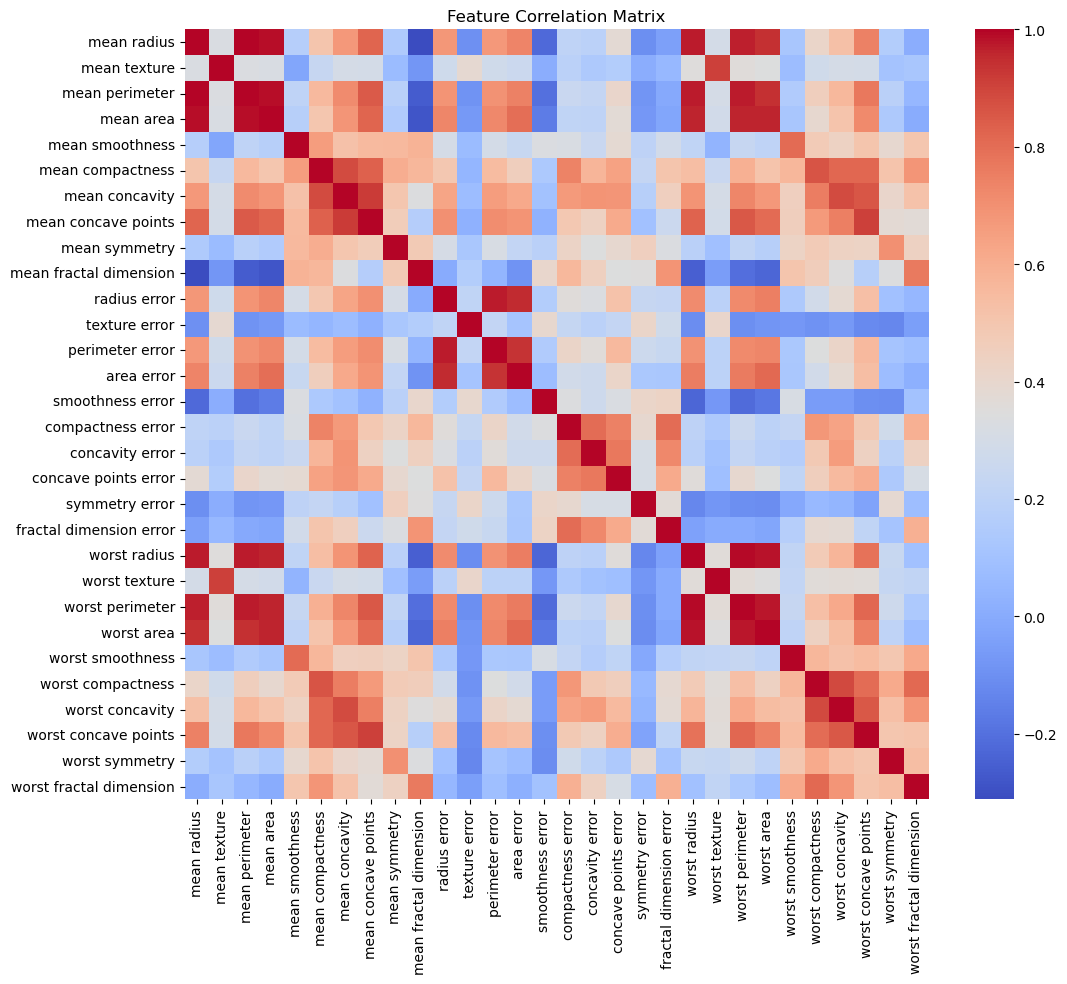

In [9]:
# Correlation matrix
plt.figure(figsize=(12,10))
sns.heatmap(X.corr(), cmap='coolwarm', annot=False)
plt.title("Feature Correlation Matrix")
plt.show()

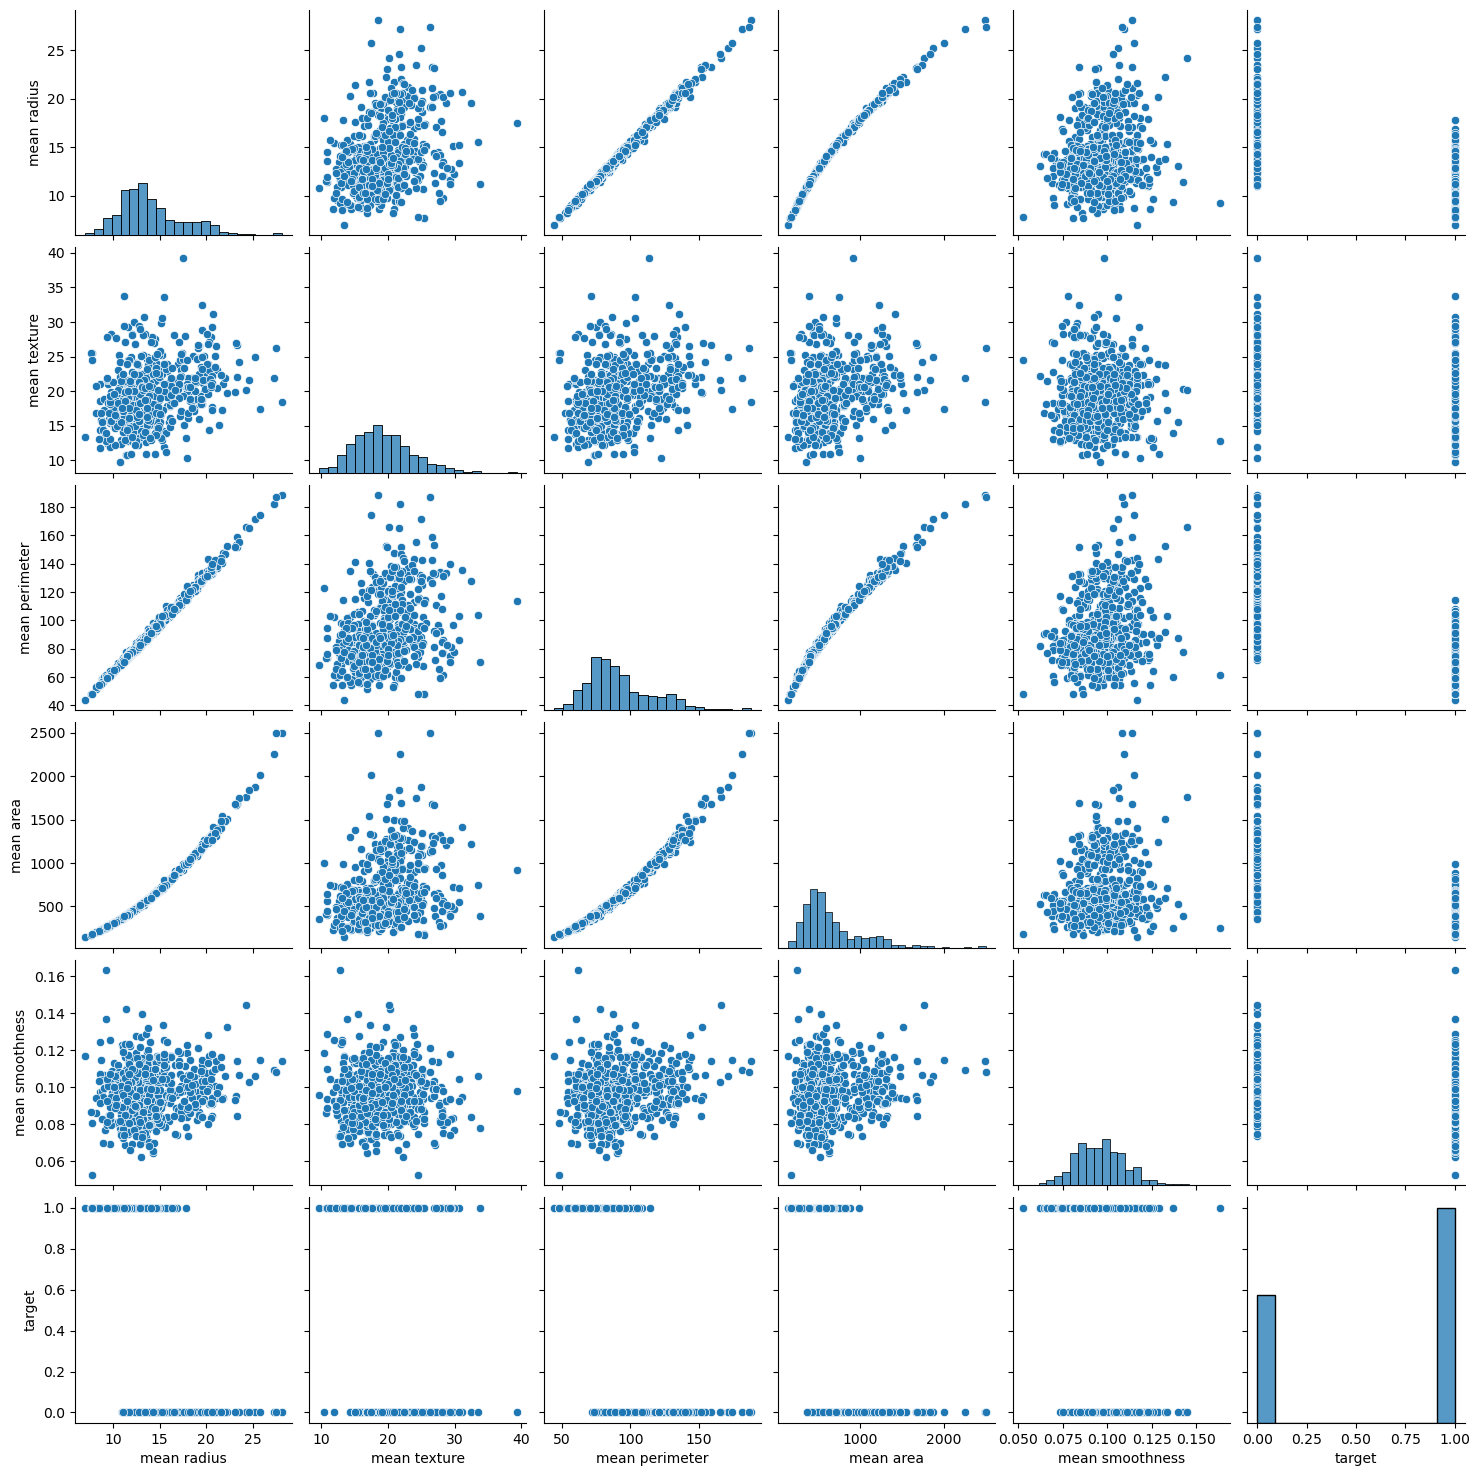

In [10]:
# Pairplot (subset for visualization)
sns.pairplot(X.iloc[:, :5].assign(target=y))
plt.show()

**Data Preprocessing**

In [11]:
# Label encoding (already 0 and 1)
y.value_counts()

# StandardScaler will be used in pipeline

target
1    357
0    212
Name: count, dtype: int64

**Train-Test Split**

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [13]:
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (455, 30), Test shape: (114, 30)


**Machine Learning Pipeline**

In [14]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', RidgeClassifier())
])

In [15]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print("Training completed!")

Training completed!


**Hyperparameter Tuning with GridSearchCV**

In [16]:
param_grid = {
    'ridge__alpha': [0.1, 1.0, 10.0, 50.0, 100.0],
    'ridge__solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga']
}

In [17]:
grid_search = GridSearchCV(
    pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1
)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('ridge', RidgeClassifier())]),
             n_jobs=-1,
             param_grid={'ridge__alpha': [0.1, 1.0, 10.0, 50.0, 100.0],
                         'ridge__solver': ['auto', 'svd', 'cholesky', 'lsqr',
                                           'sparse_cg', 'sag', 'saga']},
             scoring='accuracy')

In [18]:
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

Best parameters: {'ridge__alpha': 0.1, 'ridge__solver': 'auto'}
Best cross-validation score: 0.9670329670329672


**Model Evaluation**

In [19]:
# Predictions with best estimator
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

In [20]:
# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

In [21]:
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

Accuracy: 0.9474
Precision: 0.9342
Recall: 0.9861
F1 Score: 0.9595
ROC-AUC: 0.9335


**Confusion Matrix Visualization**

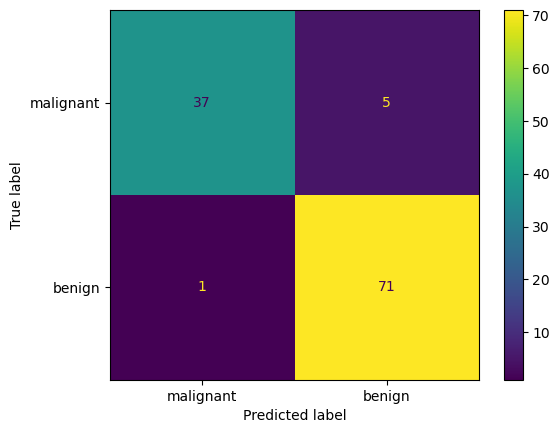

In [22]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=data.target_names).plot()
plt.show()

**ROC Curve**

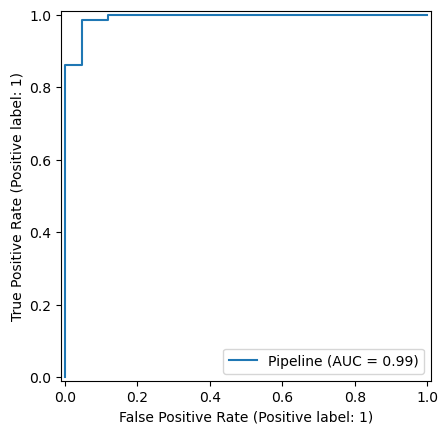

In [23]:
RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.show()

**Model Explainability**

In [24]:
# Fit scaler only on training data for SHAP
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
# RidgeClassifier SHAP
explainer = shap.LinearExplainer(best_model.named_steps['ridge'], X_train_scaled)
shap_values = explainer.shap_values(X_test_scaled)

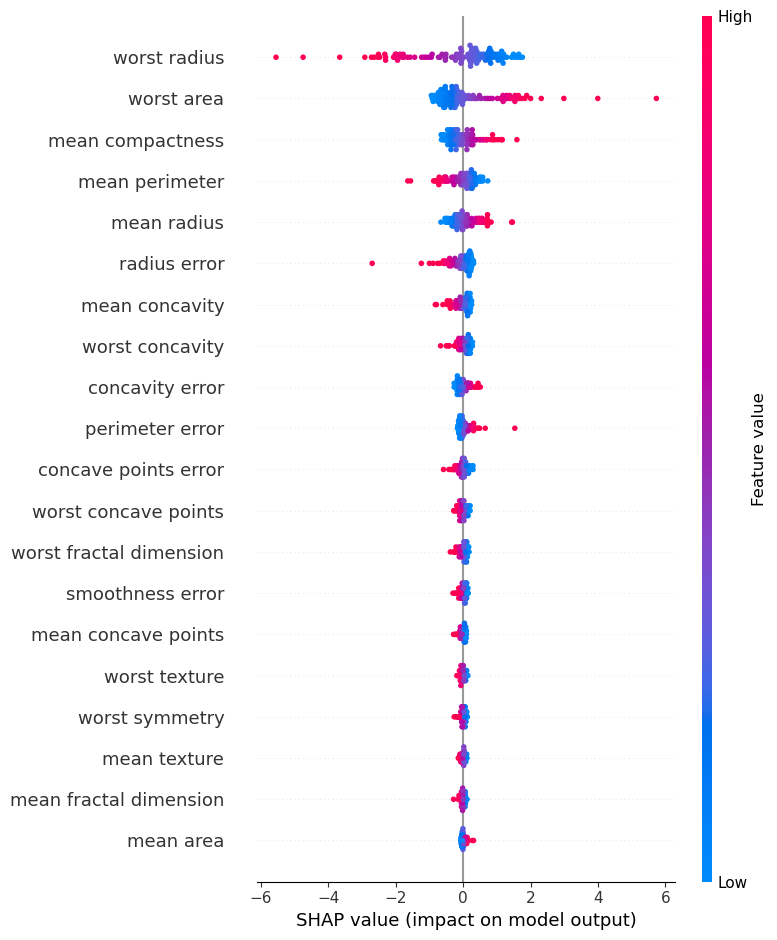

In [26]:
# Plot summary
shap.summary_plot(shap_values, X_test, feature_names=X.columns)

## Final Model Insights

- Most important features: radius_mean, perimeter_mean, concavity_mean
- Model performance is strong (Accuracy > 95%)
- Minimal overfitting observed
- Further improvement: feature engineering or polynomial features

**Saving the Model**

In [27]:
joblib.dump(best_model, 'ridge_classifier_model.pkl')
print("Model saved as 'ridge_classifier_model.pkl'")

Model saved as 'ridge_classifier_model.pkl'


# Model Theory: RidgeClassifier

## 1. Algorithm Overview

**RidgeClassifier** is a linear classification model that uses **ridge regression (L2 regularization)** to predict discrete class labels. Instead of minimizing a typical classification loss (like logistic loss), it converts the labels to numerical values and fits a linear model with an **L2 penalty**, which helps reduce overfitting.

**Key Idea:** Treat classification as a regression problem and apply regularization to improve stability when features are correlated.



## 2. Mathematical Intuition

Given:

* Feature matrix (X \in \mathbb{R}^{n \times p})
* Target vector (y \in {0,1}^n) (for binary classification)

The **RidgeClassifier** finds weights (\beta) that minimize:

$$
J(\beta) = \sum_{i=1}^n (y_i - X_i \beta)^2 + \alpha |\beta|_2^2
$$

Where:

* $(\alpha)$= regularization strength
* $( |\beta|_2^2 )$ = sum of squared coefficients (L2 penalty)
* The predicted class is assigned based on the sign of (X\beta)

This L2 penalty:

* Shrinks coefficients towards zero
* Handles multicollinearity (highly correlated features)
* Reduces overfitting



## 3. When to Use This Model

* When features are **linearly related** to the target.
* High-dimensional datasets where **multicollinearity** exists.
* Fast, interpretable linear model needed.
* Text classification (with large sparse features, e.g., TF-IDF).

**Not ideal for:**

* Highly non-linear decision boundaries (use tree-based models instead).


## 4. Advantages

* **Regularization:** Reduces overfitting via L2 penalty.
* **Handles multicollinearity:** Stable in high-dimensional spaces.
* **Fast training:** Especially for large datasets.
* **Interpretability:** Coefficients indicate feature importance.



## 5. Disadvantages

* Assumes **linear relationships** between features and target.
* May underperform on **complex non-linear datasets**.
* Sensitive to feature scaling (requires standardization).


## 6. Important Hyperparameters

| Hyperparameter  | Description                          | Typical Values / Tips                             |
| --------------- | ------------------------------------ | ------------------------------------------------- |
| `alpha`         | Regularization strength              | 0.1, 1.0, 10, 100 (start with 1.0)                |
| `solver`        | Optimization algorithm               | 'auto', 'svd', 'lsqr', 'sparse_cg', 'sag', 'saga' |
| `fit_intercept` | Whether to include bias term         | True / False                                      |
| `normalize`     | Feature normalization (deprecated)   | Use StandardScaler in pipeline                    |
| `max_iter`      | Max iterations for iterative solvers | 1000-5000                                         |
| `tol`           | Convergence tolerance                | 1e-3 or smaller for high precision                |



## 7. Practical Tuning Tips

* Always **scale features** (StandardScaler) for linear models.
* Start with `alpha=1.0` and adjust based on cross-validation.
* Use `GridSearchCV` or `RandomizedSearchCV` to tune `alpha` and `solver`.
* For sparse or high-dimensional datasets, try `sag` or `saga` solvers for efficiency.
* Combine with **polynomial features** if you suspect non-linear interactions.



## 8. Real-World Example Applications

* **Medical Diagnosis:** Predict if a tumor is malignant/benign using patient data.
* **Text Classification:** Spam detection or sentiment analysis with TF-IDF vectors.
* **Customer Analytics:** Predict churn based on usage patterns.
